In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 0 — Install Dependencies

In [2]:
# Install required libraries
!pip install deepface mtcnn --quiet
print('✅ deepface + mtcnn installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.2 MB/s eta 0:00:00
✅ deepface + mtcnn installed


## Step 1 — laod the data

In [3]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_PATH  = "/content/drive/MyDrive/pp_v2/112aligned_faces"

## Step 2 — set up

In [4]:
# ── Image / Training ──────────────────────────────────────────────────────────
IMAGE_SIZE    = (112, 112)   # ArcFace's native input
BATCH_SIZE    = 32
VAL_SPLIT     = 0.2
SEED          = 42

# ── Training hyper-params ─────────────────────────────────────────────────────
LR_PHASE1     = 1e-4         # Head-only warmup — can be aggressive
LR_PHASE2     = 5e-6         # Fine-tune — tiny, careful nudges
EPOCHS_P1     = 20
EPOCHS_P2     = 15
LR_PHASE2_FULL = 1e-6
PATIENCE      = 5            # EarlyStopping patience

print('✅ Configuration set')

✅ Configuration set


## Step 3 — Dataset Audit

In [5]:
import os
from collections import Counter

print('=== Aligned Dataset Audit ===\n')
class_folders = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

counts = {}
total_images = 0
for folder in class_folders:
    n = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, folder))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    counts[folder] = n
    total_images  += n
    print(f'  {folder:<30s}: {n} images')

NUM_CLASSES = len(class_folders)
print(f'\nTotal classes : {NUM_CLASSES}')
print(f'Total images  : {total_images}')
print(f'Avg per class : {total_images / NUM_CLASSES:.1f}')
print(f'Min per class : {min(counts.values())}')
print(f'Max per class : {max(counts.values())}')

=== Aligned Dataset Audit ===

  Lita                          : 126 images
  Makara                        : 126 images
  Rathana                       : 125 images
  Xuning                        : 125 images
  chesda                        : 125 images
  chotakna                      : 125 images
  danith                        : 125 images
  davit                         : 126 images
  deth                          : 126 images
  eun woo                       : 126 images
  iu                            : 126 images
  jay                           : 126 images
  jennie                        : 126 images
  khikhe                        : 125 images
  linghe                        : 125 images
  meng                          : 126 images
  mengheang                     : 126 images
  mony                          : 126 images
  nika                          : 126 images
  odom                          : 126 images
  ruohan                        : 126 images
  sakura                

## Step 4 — Data Pipeline with Safe Augmentation

> **Safe augmentations for faces:**  
> ✅ Horizontal flip | ✅ ±5° rotation | ✅ ±10% brightness  
> ❌ Vertical flip | ❌ Heavy crop | ❌ Extreme color distortion

In [6]:
import tensorflow as tf
import numpy as np

# ── Normalization: ArcFace standard ──────────────────────────────────────────
def normalize_arcface(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 128.0  # Range: roughly [-1, 1]
    return image, label

# ── Safe face augmentation ────────────────────────────────────────────────────
def augment_face(image, label):
    """Apply only face-safe augmentations."""
    # Horizontal flip — faces are mirror-symmetric
    image = tf.image.random_flip_left_right(image)
    # Slight brightness shift (±10%)
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Clip to valid range after brightness shift
    image = tf.clip_by_value(image, -1.0, 1.0)
    # Slight rotation ±5° — implemented via shear approximation
    # (full rotation requires tf.keras.layers.RandomRotation in the model)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# ── Build datasets from aligned folder ───────────────────────────────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

CLASS_NAMES = train_ds_raw.class_names

# ── Apply preprocessing + augmentation (train only) ──────────────────────────
train_ds = (
    train_ds_raw
    .map(normalize_arcface, num_parallel_calls=AUTOTUNE)
    .map(augment_face,      num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(normalize_arcface, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f'✅ Pipeline ready — {len(CLASS_NAMES)} classes')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Classes    : {CLASS_NAMES}')

Found 4024 files belonging to 32 classes.
Using 3220 files for training.
Found 4024 files belonging to 32 classes.
Using 804 files for validation.
✅ Pipeline ready — 32 classes
  Batch size : 32
  Classes    : ['Lita', 'Makara', 'Rathana', 'Xuning', 'chesda', 'chotakna', 'danith', 'davit', 'deth', 'eun woo', 'iu', 'jay', 'jennie', 'khikhe', 'linghe', 'meng', 'mengheang', 'mony', 'nika', 'odom', 'ruohan', 'sakura', 'samoal', 'senghut', 'simvin', 'sinta', 'sivmeng', 'sunghoon', 'tra', 'vorak', 'vuth', 'ziyu']


In [7]:
# ── Verify normalization range ────────────────────────────────────────────────
for imgs, _ in train_ds.take(1):
    print('Normalization check:')
    print(f'  Min  : {imgs.numpy().min():.4f}  (target ≈ −1.0)')
    print(f'  Max  : {imgs.numpy().max():.4f}  (target ≈  1.0)')
    print(f'  Mean : {imgs.numpy().mean():.4f}  (expect near 0)')
    print(f'  dtype: {imgs.dtype}')
    assert imgs.numpy().min() >= -1.1 and imgs.numpy().max() <= 1.1, \
        '❌ Pixel range out of bounds — check normalization!'
    print('✅ Normalization OK')

Normalization check:
  Min  : -0.9694  (target ≈ −1.0)
  Max  : 1.0000  (target ≈  1.0)
  Mean : -0.1278  (expect near 0)
  dtype: <dtype: 'float32'>
✅ Normalization OK


## Step 6 — Load Pretrained ArcFace

In [8]:
from deepface import DeepFace

arcface_client = DeepFace.build_model('ArcFace')
base_model      = arcface_client.model

print('✅ ArcFace loaded')
print(f'  Input  : {base_model.input_shape}')
print(f'  Output : {base_model.output_shape}   ← 512-dim embedding')
print(f'  Layers : {len(base_model.layers)}')
print()
print('Last 5 layers:')
for layer in base_model.layers[-5:]:
    try:
        shape = layer.output.shape
    except Exception:
        shape = 'n/a'
    print(f'  {layer.name:<45s}  {shape}')

26-05-22 13:34:14 - Directory /root/.deepface has been created
26-05-22 13:34:14 - Directory /root/.deepface/weights has been created
26-05-22 13:34:16 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:01<00:00, 88.4MB/s]


✅ ArcFace loaded
  Input  : (None, 112, 112, 3)
  Output : (None, 512)   ← 512-dim embedding
  Layers : 162

Last 5 layers:
  batch_normalization                            (None, 7, 7, 512)
  dropout                                        (None, 7, 7, 512)
  flatten                                        (None, 25088)
  dense                                          (None, 512)
  embedding                                      (None, 512)


## Step 7 — ArcFace Margin Layer

This replaces the plain `Dense + Softmax` head with an **Angular Margin** layer —
the core innovation of ArcFace. It pushes embeddings of the *same* person closer
together and embeddings of *different* people further apart on the hypersphere.

Parameters:
- **`s` (scale)** = 64 — standard for 112×112 models  
- **`m` (margin)** = 0.55 — angular gap in radians; increase for harder problems

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math

class ArcFaceLayer(keras.layers.Layer):
    """
    ArcFace Angular Margin Loss layer.

    During training  : adds margin 'm' to the ground-truth class angle,
                       then scales by 's'. Use with categorical_crossentropy.
    During inference : standard cosine similarity × s (no margin).

    Reference: Deng et al. "ArcFace: Additive Angular Margin Loss for
               Deep Face Recognition" CVPR 2019.
    """

    def __init__(self, num_classes, s=64.0, m=0.55, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.s = s
        self.m = m
        self.cos_m  = tf.cast(math.cos(m), tf.float32)
        self.sin_m  = tf.cast(math.sin(m), tf.float32)
        self.th     = tf.cast(math.cos(math.pi - m), tf.float32)
        self.mm     = tf.cast(math.sin(math.pi - m) * m, tf.float32)

    def build(self, input_shape):
        embedding_dim = input_shape[0][-1]
        self.W = self.add_weight(
            name='arcface_weights',
            shape=(embedding_dim, self.num_classes),
            initializer='glorot_uniform',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs, training=None):
        embeddings, labels = inputs  # labels: one-hot (batch, num_classes)

        # ── L2-normalize both embeddings and weights ──────────────────────────
        emb_norm = tf.nn.l2_normalize(embeddings, axis=1)        # (B, D)
        W_norm   = tf.nn.l2_normalize(self.W,      axis=0)        # (D, C)

        # ── Cosine similarity ─────────────────────────────────────────────────
        cosine = tf.matmul(emb_norm, W_norm)                       # (B, C)
        cosine = tf.clip_by_value(cosine, -1.0 + 1e-7, 1.0 - 1e-7)

        if not training:
            return cosine * self.s

        # ── Add angular margin to the ground-truth class ──────────────────────
        sine       = tf.sqrt(1.0 - tf.square(cosine))
        cos_theta_m = cosine * self.cos_m - sine * self.sin_m     # cos(θ + m)

        # Numerically stable: fall back when θ + m > π
        cos_theta_m = tf.where(
            cosine > self.th,
            cos_theta_m,
            cosine - self.mm
        )

        # labels is one-hot → pick margin for correct class only
        output = labels * cos_theta_m + (1.0 - labels) * cosine
        return output * self.s

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes, 's': self.s, 'm': self.m})
        return cfg

print('✅ ArcFaceLayer defined')

✅ ArcFaceLayer defined



## Step 8 — Build Model

Architecture:
```
Input (112,112,3)
  └─ RandomRotation(±5°)                  ← Augmentation to raw pixels first!
       └─ ArcFace Backbone                → Outputs 512-dim face embedding
            └─ BatchNormalization (head)  → Normalizes embedding space
                 └─ Dropout(0.2)          → suitable for 50+images per class
                      └─ ArcFaceLayer     → Custom angular margin weight
                           └─ Categorical Crossentropy Loss (From Logits)
```

In [10]:
from tensorflow.keras import Model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── 1. Freeze the base model completely for Phase 1 ───────────────────────────
base_model.trainable = False
for layer in base_model.layers:
    layer.trainable = False  # 👈 Crucial: explicitly freeze inner layers

# ── 2. Functional API Setup ───────────────────────────────────────────────────
inputs  = keras.Input(shape=(112, 112, 3), name='input_image')
labels  = keras.Input(shape=(NUM_CLASSES,), name='input_labels')   # for ArcFace margin

# ── 3. Data Augmentation Layer ────────────────────────────────────────────────
# Applied to raw input pixels before feature extraction
x = layers.RandomRotation(
        factor=5/360,          # ±5 degrees
        fill_mode='nearest',
        name='random_rotation'
    )(inputs)

# ── 4. Deep Face Feature Extraction ───────────────────────────────────────────
# Removed 'training=False' so Phase 2 fine-tuning can dynamically activate layers
x = base_model(x)    # Outputs (Batch_Size, 512) face embedding

# ── 5. New Classification Head Layers (The 18k Trainable Head) ────────────────
# Head BN — re-centers the embedding distribution to your specific dataset
x = layers.BatchNormalization(name='bn_head')(x)

# Dropout — regularizes the 512-dim vector (Tweakable hyperparameter)
x = layers.Dropout(0.2, name='dropout')(x)

# Custom ArcFace Layer — apply angular margin penalties to weights
logits = ArcFaceLayer(NUM_CLASSES, s=64.0, m=0.55, name='arcface_margin')([x, labels])

outputs = logits
model = Model(inputs=[inputs, labels], outputs=outputs, name='ArcFace_Pro')

# ── 6. Parameter Verification Summary ─────────────────────────────────────────
total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = total - trainable
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}   ← head only (Phase 1 warmup)')
print(f'Frozen params    : {frozen:,}   ← ArcFace base backbone')

Total params     : 34,183,616
Trainable params : 17,408   ← head only (Phase 1 warmup)
Frozen params    : 34,166,208   ← ArcFace base backbone


## Step 9 — Training Helpers (Dataset Adaptor)

The ArcFace model now takes **two inputs** `(image, one-hot label)` instead of one.
We need a small wrapper to feed both from our existing `tf.data` pipeline.

In [11]:
def adapt_for_arcface(image, label):
    """Return ({input_image: img, input_labels: label}, label) for Keras.fit."""
    return {'input_image': image, 'input_labels': label}, label

train_ds_arc = train_ds.map(adapt_for_arcface, num_parallel_calls=AUTOTUNE)
val_ds_arc   = val_ds.map(adapt_for_arcface,   num_parallel_calls=AUTOTUNE)

print('✅ Dataset adapted for two-input ArcFace model')

✅ Dataset adapted for two-input ArcFace model


## Step 10 — Phase 1: Head Warmup (Base Frozen)

The base ArcFace weights are **completely frozen**. Only the head (BN + Dropout + ArcFaceLayer)
is trained. This prevents the random head weights from corrupting the pretrained features.

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_acc',
        mode='max',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

print('PHASE 1 — Head warmup (base frozen)')
print(f'Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}\n')

history_p1 = model.fit(
    train_ds_arc,
    validation_data=val_ds_arc,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
    verbose=1,
)

PHASE 1 — Head warmup (base frozen)
Trainable params: 17,408

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 587s 6s/step - acc: 0.0000e+00 - loss: 38.7703 - val_acc: 0.1045 - val_loss: 4.1531 - learning_rate: 1.0000e-04
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - acc: 0.0000e+00 - loss: 36.8652 - val_acc: 0.3843 - val_loss: 2.2423 - learning_rate: 1.0000e-04
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - acc: 0.0000e+00 - loss: 35.2171 - val_acc: 0.6692 - val_loss: 1.1376 - learning_rate: 1.0000e-04
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - acc: 0.0000e+00 - loss: 33.7520 - val_acc: 0.8308 - val_loss: 0.6069 - learning_rate: 1.0000e-04
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - acc: 0.0000e+00 - loss: 32.3928 - val_acc: 0.8968 - val_loss: 0.3571 - learning_rate: 1.0000e-04
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - acc: 0.0000e+00 - loss: 31.1518 - val_acc: 0.9366 - val_loss: 0.2360 - learning_rate: 1.0000e-04
Epoch 7/20
101/1

## Step 11 — Phase 2: Selective Fine-Tuning

### Strategy: Unfreeze only the top conv blocks — **keep BatchNorm frozen**

Why freeze BN?
- BN stores `moving_mean` and `moving_variance` computed over millions of faces.
- Updating these on our small dataset (900 images) causes **catastrophic drift**.
- Freezing BN lets us fine-tune conv weights without destroying the statistics.

Optimizer: **SGD + Momentum** (not Adam) — researchers consistently find
SGD converges to better minima for fine-tuning face recognition models.

In [13]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
import os

# ── 1. Full Unfreeze (Except Batch Normalization) ─────────────────────────────
base_model.trainable = True

# CRITICAL CHANGE: We do NOT use a cutoff anymore. We keep all non-BN layers trainable.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Keep ALL Batch Normalization layers completely frozen
        layer.trainable = False
    else:
        # Unfreeze every other layer (Convolutional, Dense, etc.)
        layer.trainable = True

# ── 2. Recompile with SGD + Momentum (Using a Smaller Learning Rate) ──────────
# CRITICAL CHANGE: Set LR lower (e.g., 1e-5 or 1e-6) because unfreezing all layers
# makes training highly sensitive. If it's too high, your loss will become 'NaN'.
LR_FULL_LAYERS = 1e-5

model.compile(
    optimizer=SGD(
        learning_rate=LR_FULL_LAYERS,
        momentum=0.9,
        nesterov=True
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='acc')]
)

# ── 3. Drive Checkpoint Setup & Callbacks ─────────────────────────────────────
# This protects your progress if Google Colab disconnects mid-test
checkpoint_dir = "/content/drive/MyDrive/pp_v2/checkpoints/full_layer_test"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_weights.weights.h5")

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_acc',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks_p2_full = [
    EarlyStopping(
        monitor='val_acc',
        patience=PATIENCE + 2,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    checkpoint_callback # 👈 Added the Google Drive saver here
]

# ── 4. Parameter Verification ─────────────────────────────────────────────────
trainable_now = sum(tf.size(w).numpy() for w in model.trainable_weights)
print('PHASE 2 — FULL layer fine-tuning (BN frozen throughout)')
print(f'Trainable params : {trainable_now:,}  ← This should now show 20M+ parameters\n')

# ── 5. Execute Fine-Tuning ────────────────────────────────────────────────────
# Increased epochs slightly because the learning rate is smaller and needs more time
EPOCHS_P2_FULL = 25

history_p2 = model.fit(
    train_ds_arc,
    validation_data=val_ds_arc,
    epochs=EPOCHS_P2_FULL,
    callbacks=callbacks_p2_full,
    verbose=1,
)

PHASE 2 — FULL layer fine-tuning (BN frozen throughout)
Trainable params : 34,130,880  ← This should now show 20M+ parameters

Epoch 1/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - acc: 0.0018 - loss: 20.8222
Epoch 1: val_acc improved from None to 0.98756, saving model to /content/drive/MyDrive/pp_v2/checkpoints/full_layer_test/best_weights.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/pp_v2/checkpoints/full_layer_test/best_weights.weights.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 436ms/step - acc: 0.0031 - loss: 20.4443 - val_acc: 0.9876 - val_loss: 0.0491 - learning_rate: 1.0000e-05
Epoch 2/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - acc: 0.0029 - loss: 19.5296
Epoch 2: val_acc improved from 0.98756 to 0.99129, saving model to /content/drive/MyDrive/pp_v2/checkpoints/full_layer_test/best_weights.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/pp_v2/checkpoints/full_layer_test/best_weights.weights.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 43s 424ms/st

testing

In [14]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ────────────

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp/test/photo_26_2026-05-09_04-53-43.jpg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if not results:
        return None

    r = max(results, key=lambda x:x['confidence'])

    kp = r['keypoints']

    le = np.array(kp['left_eye'])
    re = np.array(kp['right_eye'])

    dy = re[1] - le[1]
    dx = re[0] - le[0]

    angle = np.degrees(np.arctan2(dy, dx))

    center = (
        (le[0] + re[0]) / 2,
        (le[1] + re[1]) / 2
    )

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    h, w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(img_rgb, M, (w, h))

    x, y, bw, bh = r['box']

    margin = int(max(bw, bh) * 0.10)

    x1 = max(0, x-margin)
    y1 = max(0, y-margin)

    x2 = min(w, x+bw+margin)
    y2 = min(h, y+bh+margin)

    face = rotated[y1:y2, x1:x2]

    face = cv2.resize(face, target_size)

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(img)

    img_float = (aligned.astype(np.float32) - 127.5) / 128.0

    return img_float


# Prepare image
img_norm = align_single_image(INSPECTION_IMAGE)

img_batch = np.expand_dims(img_norm, axis=0)

dummy_labels = np.zeros((1, NUM_CLASSES), dtype=np.float32)

# ArcFace raw output
raw_logits = model(
    {
        'input_image': img_batch,
        'input_labels': dummy_labels
    },
    training=False
).numpy()[0]

print("\n── Raw ArcFace output (cosine × 64) ──")

for name, val in zip(CLASS_NAMES, raw_logits):

    print(f"{name:20s} {val:8.3f}")


# Softmax inspection
softmax_probs = tf.nn.softmax(raw_logits).numpy()

print("\n── Softmax output ──")

for name, p in sorted(
    zip(CLASS_NAMES, softmax_probs),
    key=lambda x:-x[1]
):

    print(f"{name:20s} {p*100:5.1f}%")


# Winner
best_idx = np.argmax(raw_logits)

print("\nPredicted identity:", CLASS_NAMES[best_idx])

print("Raw score:", raw_logits[best_idx])


── Raw ArcFace output (cosine × 64) ──
Lita                   -1.275
Makara                 -3.933
Rathana                10.446
Xuning                 -2.023
chesda                  7.173
chotakna               -0.826
danith                 -0.135
davit                  -0.219
deth                   -3.668
eun woo                -1.721
iu                     -5.995
jay                     2.227
jennie                  3.627
khikhe                 -3.824
linghe                 -5.233
meng                    0.955
mengheang              -3.249
mony                   -2.371
nika                   31.964
odom                   -3.219
ruohan                  2.807
sakura                 -2.448
samoal                 -4.412
senghut                -2.009
simvin                  2.556
sinta                   6.685
sivmeng                 3.339
sunghoon               -2.837
tra                    -5.955
vorak                  -6.352
vuth                   -3.902
ziyu                    3.315


In [15]:
import math

# ── Recover cosine from ArcFace logits ─────────────────────────────

def logit_to_true_cosine(logit, scale=64.0, margin=0.5):

    penalized_cos = np.clip(logit / scale, -1.0, 1.0)

    penalized_theta = math.acos(penalized_cos)

    true_theta = max(0.0, penalized_theta - margin)

    return math.cos(true_theta)


print("\n── Recovered cosine similarity ──")

for name, val in sorted(
    zip(CLASS_NAMES, raw_logits),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(val)

    print(
        f"{name:20s} "
        f"logit={val:8.3f} "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
nika                 logit=  31.964 cos=0.8537
Rathana              logit=  10.446 cos=0.6162
chesda               logit=   7.173 cos=0.5748
sinta                logit=   6.685 cos=0.5685
jennie               logit=   3.627 cos=0.5284
sivmeng              logit=   3.339 cos=0.5246
ziyu                 logit=   3.315 cos=0.5242
ruohan               logit=   2.807 cos=0.5175
simvin               logit=   2.556 cos=0.5141
jay                  logit=   2.227 cos=0.5097
meng                 logit=   0.955 cos=0.4925
danith               logit=  -0.135 cos=0.4776
davit                logit=  -0.219 cos=0.4764
chotakna             logit=  -0.826 cos=0.4681
Lita                 logit=  -1.275 cos=0.4619
eun woo              logit=  -1.721 cos=0.4557
senghut              logit=  -2.009 cos=0.4516
Xuning               logit=  -2.023 cos=0.4514
mony                 logit=  -2.371 cos=0.4466
sakura               logit=  -2.448 cos=0.4455
sunghoon             logi

In [16]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ────────────

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if not results:
        return None

    r = max(results, key=lambda x:x['confidence'])

    kp = r['keypoints']

    le = np.array(kp['left_eye'])
    re = np.array(kp['right_eye'])

    dy = re[1] - le[1]
    dx = re[0] - le[0]

    angle = np.degrees(np.arctan2(dy, dx))

    center = (
        (le[0] + re[0]) / 2,
        (le[1] + re[1]) / 2
    )

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    h, w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(img_rgb, M, (w, h))

    x, y, bw, bh = r['box']

    margin = int(max(bw, bh) * 0.10)

    x1 = max(0, x-margin)
    y1 = max(0, y-margin)

    x2 = min(w, x+bw+margin)
    y2 = min(h, y+bh+margin)

    face = rotated[y1:y2, x1:x2]

    face = cv2.resize(face, target_size)

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(img)

    img_float = (aligned.astype(np.float32) - 127.5) / 128.0

    return img_float


# Prepare image
img_norm = align_single_image(INSPECTION_IMAGE)

img_batch = np.expand_dims(img_norm, axis=0)

dummy_labels = np.zeros((1, NUM_CLASSES), dtype=np.float32)

# ArcFace raw output
raw_logits = model(
    {
        'input_image': img_batch,
        'input_labels': dummy_labels
    },
    training=False
).numpy()[0]

print("\n── Raw ArcFace output (cosine × 64) ──")

for name, val in zip(CLASS_NAMES, raw_logits):

    print(f"{name:20s} {val:8.3f}")


# Softmax inspection
softmax_probs = tf.nn.softmax(raw_logits).numpy()

print("\n── Softmax output ──")

for name, p in sorted(
    zip(CLASS_NAMES, softmax_probs),
    key=lambda x:-x[1]
):

    print(f"{name:20s} {p*100:5.1f}%")


# Winner
best_idx = np.argmax(raw_logits)

print("\nPredicted identity:", CLASS_NAMES[best_idx])

print("Raw score:", raw_logits[best_idx])


── Raw ArcFace output (cosine × 64) ──
Lita                    9.782
Makara                 11.806
Rathana                 6.385
Xuning                 -3.785
chesda                -10.686
chotakna               -1.783
danith                 11.141
davit                  -2.333
deth                   -9.714
eun woo                -6.968
iu                     19.022
jay                    -0.585
jennie                  2.080
khikhe                 -1.542
linghe                 -7.658
meng                    0.460
mengheang              -7.207
mony                    1.649
nika                   -2.862
odom                   -0.358
ruohan                 -1.390
sakura                  5.072
samoal                 -7.109
senghut                -6.631
simvin                 -2.856
sinta                  -2.112
sivmeng                 7.292
sunghoon               -3.040
tra                    -0.831
vorak                   3.598
vuth                   -0.663
ziyu                    0.828


In [17]:
import math

# ── Recover cosine from ArcFace logits ─────────────────────────────

def logit_to_true_cosine(logit, scale=64.0, margin=0.5):

    penalized_cos = np.clip(logit / scale, -1.0, 1.0)

    penalized_theta = math.acos(penalized_cos)

    true_theta = max(0.0, penalized_theta - margin)

    return math.cos(true_theta)


print("\n── Recovered cosine similarity ──")

for name, val in sorted(
    zip(CLASS_NAMES, raw_logits),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(val)

    print(
        f"{name:20s} "
        f"logit={val:8.3f} "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
iu                   logit=  19.022 cos=0.7186
Makara               logit=  11.806 cos=0.6331
danith               logit=  11.141 cos=0.6249
Lita                 logit=   9.782 cos=0.6079
sivmeng              logit=   7.292 cos=0.5763
Rathana              logit=   6.385 cos=0.5646
sakura               logit=   5.072 cos=0.5475
vorak                logit=   3.598 cos=0.5280
jennie               logit=   2.080 cos=0.5077
mony                 logit=   1.649 cos=0.5019
ziyu                 logit=   0.828 cos=0.4907
meng                 logit=   0.460 cos=0.4857
odom                 logit=  -0.358 cos=0.4745
jay                  logit=  -0.585 cos=0.4714
vuth                 logit=  -0.663 cos=0.4703
tra                  logit=  -0.831 cos=0.4680
ruohan               logit=  -1.390 cos=0.4603
khikhe               logit=  -1.542 cos=0.4581
chotakna             logit=  -1.783 cos=0.4548
sinta                logit=  -2.112 cos=0.4502
davit                logi

In [18]:
# ── Run this cell RIGHT AFTER TRAINING to inspect ArcFace outputs ────────────

import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN

# Test image
INSPECTION_IMAGE = "/content/drive/MyDrive/pp_v2/test/4B26123F-862B-473A-9C21-EF576176C331 - ធឿន សុខលីន.jpeg"

detector = MTCNN()

def align_and_crop(img_bgr, target_size=(112,112)):

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if not results:
        return None

    r = max(results, key=lambda x:x['confidence'])

    kp = r['keypoints']

    le = np.array(kp['left_eye'])
    re = np.array(kp['right_eye'])

    dy = re[1] - le[1]
    dx = re[0] - le[0]

    angle = np.degrees(np.arctan2(dy, dx))

    center = (
        (le[0] + re[0]) / 2,
        (le[1] + re[1]) / 2
    )

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    h, w = img_rgb.shape[:2]

    rotated = cv2.warpAffine(img_rgb, M, (w, h))

    x, y, bw, bh = r['box']

    margin = int(max(bw, bh) * 0.10)

    x1 = max(0, x-margin)
    y1 = max(0, y-margin)

    x2 = min(w, x+bw+margin)
    y2 = min(h, y+bh+margin)

    face = rotated[y1:y2, x1:x2]

    face = cv2.resize(face, target_size)

    return face


def align_single_image(path):

    img = cv2.imread(path)

    aligned = align_and_crop(img)

    img_float = (aligned.astype(np.float32) - 127.5) / 128.0

    return img_float


# Prepare image
img_norm = align_single_image(INSPECTION_IMAGE)

img_batch = np.expand_dims(img_norm, axis=0)

dummy_labels = np.zeros((1, NUM_CLASSES), dtype=np.float32)

# ArcFace raw output
raw_logits = model(
    {
        'input_image': img_batch,
        'input_labels': dummy_labels
    },
    training=False
).numpy()[0]

print("\n── Raw ArcFace output (cosine × 64) ──")

for name, val in zip(CLASS_NAMES, raw_logits):

    print(f"{name:20s} {val:8.3f}")


# Softmax inspection
softmax_probs = tf.nn.softmax(raw_logits).numpy()

print("\n── Softmax output ──")

for name, p in sorted(
    zip(CLASS_NAMES, softmax_probs),
    key=lambda x:-x[1]
):

    print(f"{name:20s} {p*100:5.1f}%")


# Winner
best_idx = np.argmax(raw_logits)

print("\nPredicted identity:", CLASS_NAMES[best_idx])

print("Raw score:", raw_logits[best_idx])


── Raw ArcFace output (cosine × 64) ──
Lita                    4.107
Makara                  6.672
Rathana                 4.566
Xuning                  1.542
chesda                  8.185
chotakna                4.055
danith                 -6.206
davit                  -4.248
deth                    1.831
eun woo                 7.197
iu                     -5.791
jay                     1.911
jennie                  2.776
khikhe                 -1.995
linghe                  2.048
meng                   -2.550
mengheang               3.605
mony                    3.640
nika                   -0.639
odom                   -0.025
ruohan                  8.900
sakura                 -3.457
samoal                 -4.583
senghut                 1.477
simvin                 -6.168
sinta                   5.243
sivmeng                -4.588
sunghoon                4.399
tra                    -5.484
vorak                  -5.032
vuth                   -8.424
ziyu                   -7.488


In [19]:
import math

# ── Recover cosine from ArcFace logits ─────────────────────────────

def logit_to_true_cosine(logit, scale=64.0, margin=0.5):

    penalized_cos = np.clip(logit / scale, -1.0, 1.0)

    penalized_theta = math.acos(penalized_cos)

    true_theta = max(0.0, penalized_theta - margin)

    return math.cos(true_theta)


print("\n── Recovered cosine similarity ──")

for name, val in sorted(
    zip(CLASS_NAMES, raw_logits),
    key=lambda x:-x[1]
):

    cos_val = logit_to_true_cosine(val)

    print(
        f"{name:20s} "
        f"logit={val:8.3f} "
        f"cos={cos_val:.4f}"
    )


── Recovered cosine similarity ──
ruohan               logit=   8.900 cos=0.5968
chesda               logit=   8.185 cos=0.5877
eun woo              logit=   7.197 cos=0.5751
Makara               logit=   6.672 cos=0.5683
sinta                logit=   5.243 cos=0.5497
Rathana              logit=   4.566 cos=0.5408
sunghoon             logit=   4.399 cos=0.5386
Lita                 logit=   4.107 cos=0.5347
chotakna             logit=   4.055 cos=0.5341
mony                 logit=   3.640 cos=0.5286
mengheang            logit=   3.605 cos=0.5281
jennie               logit=   2.776 cos=0.5170
linghe               logit=   2.048 cos=0.5073
jay                  logit=   1.911 cos=0.5054
deth                 logit=   1.831 cos=0.5043
Xuning               logit=   1.542 cos=0.5004
senghut              logit=   1.477 cos=0.4995
odom                 logit=  -0.025 cos=0.4791
nika                 logit=  -0.639 cos=0.4706
khikhe               logit=  -1.995 cos=0.4518
meng                 logi

## Step 13 — Save Model

In [20]:
SAVE_PATH = '/content/drive/MyDrive/pp_v2/test2/arcface_finetuned_112v1.keras'

# Save full model (weights + architecture + optimizer state)
model.save(SAVE_PATH)
print(f'✅ Model saved → {SAVE_PATH}')

# Save class names alongside the model
import json
with open('/content/drive/MyDrive/pp_v2/test2/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print(f'✅ Class names saved')

✅ Model saved → /content/drive/MyDrive/pp_v2/test2/arcface_finetuned_112v1.keras
✅ Class names saved


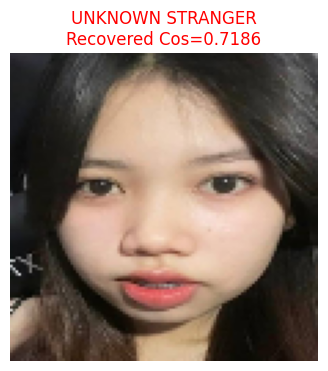

Target Processed    : /content/drive/MyDrive/pp_v2/test/ttt1.jpg
System Label Result : UNKNOWN STRANGER
Recovered Cosine    : 0.7186
🚨 Access Denied!


In [24]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN
import math

# ── CONFIG ─────────────────────────────────────────────────────────
TEST_IMAGE_PATH = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"

# Recovered cosine threshold
OPENS_THRESHOLD = 0.75

detector = MTCNN()

# ── FACE ALIGN + PREPROCESS ───────────────────────────────────────
def align_and_crop_face(image_path, target_size=(112,112)):

    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        raise FileNotFoundError(image_path)

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    results = detector.detect_faces(img_rgb)

    # fallback if detection fails
    if not results:

        aligned = cv2.resize(
            img_rgb,
            target_size
        )

    else:

        r = max(
            results,
            key=lambda x:x['confidence']
        )

        kp = r['keypoints']

        le = np.array(kp['left_eye'])
        re = np.array(kp['right_eye'])

        dy = re[1] - le[1]
        dx = re[0] - le[0]

        angle = np.degrees(
            np.arctan2(dy,dx)
        )

        center = (
            (le[0]+re[0])/2,
            (le[1]+re[1])/2
        )

        M = cv2.getRotationMatrix2D(
            center,
            angle,
            1.0
        )

        h,w = img_rgb.shape[:2]

        rotated = cv2.warpAffine(
            img_rgb,
            M,
            (w,h)
        )

        x,y,bw,bh = r['box']

        margin = int(
            max(bw,bh)*0.10
        )

        x1=max(0,x-margin)
        y1=max(0,y-margin)

        x2=min(w,x+bw+margin)
        y2=min(h,y+bh+margin)

        face = rotated[
            y1:y2,
            x1:x2
        ]

        if face.size == 0:

            aligned = cv2.resize(
                img_rgb,
                target_size
            )

        else:

            aligned = cv2.resize(
                face,
                target_size
            )

    img_norm = (
        aligned.astype(np.float32)-127.5
    ) / 128.0

    return img_norm, aligned


# ── RECOVER REAL COSINE ───────────────────────────────────────────
def recover_true_cosine(logit, scale=64.0, margin=0.5):

    penalized = np.clip(
        logit/scale,
        -1.0,
        1.0
    )

    theta_margin = math.acos(
        penalized
    )

    theta = max(
        0.0,
        theta_margin-margin
    )

    return math.cos(theta)


# ── OPEN SET INFERENCE ────────────────────────────────────────────
def run_open_set_inference(
    image_path,
    trained_model,
    classes,
    total_classes,
    threshold=0.65
):

    img_norm, img_display = align_and_crop_face(
        image_path
    )

    img_batch = np.expand_dims(
        img_norm,
        axis=0
    )

    dummy_labels = np.zeros(
        (1,total_classes),
        dtype=np.float32
    )

    logits = trained_model(
        {
            'input_image':img_batch,
            'input_labels':dummy_labels
        },
        training=False
    )

    true_cosines = np.array([
        recover_true_cosine(v)
        for v in logits.numpy()[0]
    ])

    pred_idx = np.argmax(
        true_cosines
    )

    highest_similarity = float(
        true_cosines[pred_idx]
    )

    if highest_similarity >= threshold:

        pred_name = classes[pred_idx]

        is_known = True

    else:

        pred_name = "UNKNOWN STRANGER"

        is_known = False

    return (
        pred_name,
        highest_similarity,
        is_known,
        img_display
    )


# ── EXECUTE ───────────────────────────────────────────────────────
pred_name, sim_score, is_auth, display_img = run_open_set_inference(
    image_path=TEST_IMAGE_PATH,
    trained_model=model,
    classes=CLASS_NAMES,
    total_classes=NUM_CLASSES,
    threshold=OPENS_THRESHOLD
)

plt.figure(figsize=(4,4))

plt.imshow(display_img)

color = 'green' if is_auth else 'red'

plt.title(
    f'{pred_name}\nRecovered Cos={sim_score:.4f}',
    color=color
)

plt.axis('off')

plt.show()


print(
    f"Target Processed    : {TEST_IMAGE_PATH}"
)

print(
    f"System Label Result : {pred_name}"
)

print(
    f"Recovered Cosine    : {sim_score:.4f}"
)

if not is_auth:

    print(
        "🚨 Access Denied!"
    )

## Step 14 — Inference (Single Image Prediction)

At inference the `input_labels` is a dummy zero tensor — the ArcFace layer
detects `training=False` and skips the margin, returning plain cosine × scale.

import cv2
import numpy as np
from mtcnn import MTCNN
from PIL import Image
import shutil

detector = MTCNN()
def align_and_crop(img_bgr, target_size=(112, 112)):
    """
    Detect face, align by rotating so eyes are horizontal, crop tightly.
    Returns aligned RGB image (HxWx3 uint8) or None if no face found.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if not results:
        return None  # No face detected — skip this image

    # Use the detection with highest confidence
    r = max(results, key=lambda x: x['confidence'])

    # ── Alignment: rotate so eyes are horizontal ──────────────────────────────
    kp    = r['keypoints']
    le, re = np.array(kp['left_eye']), np.array(kp['right_eye'])
    dy, dx = re[1] - le[1], re[0] - le[0]
    angle  = np.degrees(np.arctan2(dy, dx))

    center = ((le[0] + re[0]) / 2, (le[1] + re[1]) / 2)
    M      = cv2.getRotationMatrix2D(center, angle, 1.0)
    h, w   = img_rgb.shape[:2]
    rotated = cv2.warpAffine(img_rgb, M, (w, h), flags=cv2.INTER_LINEAR)

    # ── Crop: use bounding box from original detection ────────────────────────
    x, y, bw, bh = r['box']
    # Add 10% margin on each side so we don't cut ears
    margin = int(max(bw, bh) * 0.10)
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(w, x + bw + margin)
    y2 = min(h, y + bh + margin)

    face = rotated[y1:y2, x1:x2]
    if face.size == 0:
        return None

    # ── Resize to ArcFace native 112×112 ──────────────────────────────────────
    face_resized = cv2.resize(face, target_size, interpolation=cv2.INTER_LINEAR)
    return face_resized  # RGB uint8

import numpy as np
import cv2
import matplotlib.pyplot as plt


TEST_IMAGE = "/content/drive/MyDrive/pp_v2/test/ttt1.jpg"

def align_single_image(image_path, target_size=(112, 112)):
    """Align and normalize a single test image exactly like training data."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read: {image_path}')
    aligned = align_and_crop(img_bgr, target_size)
    if aligned is None:
        print('⚠️  No face detected — using resized original')
        aligned = cv2.resize(
            cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
            target_size
        )
    # Normalize to [-1, 1] — ArcFace standard
    img_float = (aligned.astype(np.float32) - 127.5) / 128.0
    return img_float, aligned   # normalized + display copy


def predict_person(image_path, model, class_names, num_classes):

    img_norm, img_display = align_single_image(image_path)

    img_batch = np.expand_dims(img_norm, axis=0)

    dummy_labels = np.zeros((1, num_classes), dtype=np.float32)

    logits = model(
        {
            'input_image': img_batch,
            'input_labels': dummy_labels
        },
        training=False
    )

    probs = tf.nn.softmax(logits, axis=1).numpy()

    pred_idx = np.argmax(probs[0])

    confidence = float(probs[0][pred_idx])

    pred_name = class_names[pred_idx]

    return pred_name, confidence, img_display


# ── Run prediction ────────────────────────────────────────────────────────────
pred_name, confidence, display_img = predict_person(
    TEST_IMAGE, model, CLASS_NAMES, NUM_CLASSES
)

plt.figure(figsize=(4, 4))
plt.imshow(display_img)
color = 'green' if confidence > 0.7 else ('orange' if confidence > 0.4 else 'red')
plt.title(
    f'Predicted : {pred_name}\nConfidence: {confidence*100:.1f}%',
    fontsize=12, color=color
)
plt.axis('off')
plt.show()

print(f'Predicted  : {pred_name}')
print(f'Confidence : {confidence*100:.2f}%')
if confidence < 0.4:
    print('⚠️  Low confidence — consider more training data for this person.')

## Step 12 — Training Curves

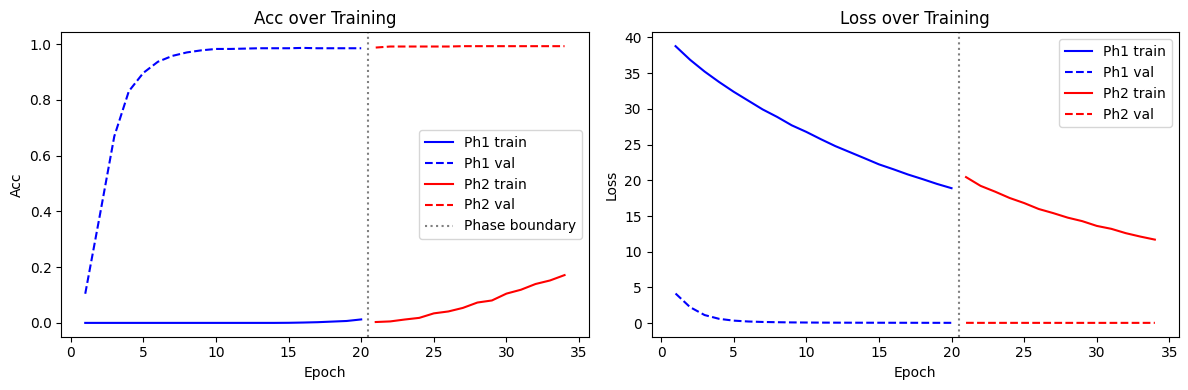

✅ Saved to /content/training_curves.png


In [25]:
import matplotlib.pyplot as plt

def plot_history(h1, h2, metric='acc'):
    v1 = h1.history[metric]
    vv1 = h1.history[f'val_{metric}']
    v2 = h2.history[metric]
    vv2 = h2.history[f'val_{metric}']

    ep1 = range(1, len(v1) + 1)
    ep2 = range(len(v1) + 1, len(v1) + len(v2) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(ep1, v1,  'b-',  label='Ph1 train')
    plt.plot(ep1, vv1, 'b--', label='Ph1 val')
    plt.plot(ep2, v2,  'r-',  label='Ph2 train')
    plt.plot(ep2, vv2, 'r--', label='Ph2 val')
    plt.axvline(len(v1) + 0.5, color='gray', linestyle=':', label='Phase boundary')
    plt.xlabel('Epoch'); plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} over Training'); plt.legend()

    plt.subplot(1, 2, 2)
    loss1  = h1.history['loss']
    vloss1 = h1.history['val_loss']
    loss2  = h2.history['loss']
    vloss2 = h2.history['val_loss']
    plt.plot(ep1, loss1,  'b-',  label='Ph1 train')
    plt.plot(ep1, vloss1, 'b--', label='Ph1 val')
    plt.plot(ep2, loss2,  'r-',  label='Ph2 train')
    plt.plot(ep2, vloss2, 'r--', label='Ph2 val')
    plt.axvline(len(v1) + 0.5, color='gray', linestyle=':')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss over Training'); plt.legend()

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150)
    plt.show()
    print('✅ Saved to /content/training_curves.png')

plot_history(history_p1, history_p2)